
dt=0.001, seed=0, Nsteps=100,000, LJ time=100, log period=500 steps

dt=0.001, seed=1, Nsteps=100,000, LJ time=100, log period=500 steps

dt=0.001, seed=2, Nsteps=100,000, LJ time=100, log period=500 steps

dt=0.001, seed=3, Nsteps=100,000, LJ time=100, log period=500 steps

dt=0.001, seed=4, Nsteps=100,000, LJ time=100, log period=500 steps

dt=0.001, seed=5, Nsteps=100,000, LJ time=100, log period=500 steps

dt=0.001, seed=6, Nsteps=100,000, LJ time=100, log period=500 steps

dt=0.001, seed=7, Nsteps=100,000, LJ time=100, log period=500 steps

dt=0.001, seed=8, Nsteps=100,000, LJ time=100, log period=500 steps

dt=0.001, seed=9, Nsteps=100,000, LJ time=100, log period=500 steps

dt=0.002, seed=0, Nsteps=50,000, LJ time=100, log period=250 steps

dt=0.002, seed=1, Nsteps=50,000, LJ time=100, log period=250 steps

dt=0.002, seed=2, Nsteps=50,000, LJ time=100, log period=250 steps

dt=0.002, seed=3, Nsteps=50,000, LJ time=100, log period=250 steps

dt=0.002, seed=4, Nsteps=50,000, LJ t

,Run_ID,dt,seed,Nsteps,actual_lj_time,log_period,log_lj_interval,summary_samples,pressure_mean,pressure_std,pressure_sem,pe_per_particle_mean,pe_per_particle_std,pe_per_particle_sem,reused_existing_run
0,20260910192014,0.0010,0,100000,100.0,500,0.5,100,0.021432,0.009898,0.000990,-4.448847,0.002194,0.000219,True
1,20260910193516,0.0020,0,50000,100.0,250,0.5,100,0.024222,0.010002,0.001000,-4.448302,0.002211,0.000221,True
2,20260910194344,0.0025,0,40000,100.0,200,0.5,100,0.023948,0.011304,0.001130,-4.448220,0.002173,0.000217,True
3,20260910195049,0.0050,0,20000,100.0,100,0.5,100,0.025287,0.011388,0.001139,-4.447952,0.002503,0.000250,True
4,20260910195513,0.0100,0,10000,100.0,50,0.5,100,0.031367,0.011248,0.001125,-4.445279,0.002478,0.000248,True
5,20260910182541,0.0010,1,100000,100.0,500,0.5,100,0.024401,0.010662,0.001066,-4.448487,0.002544,0.000254,True
6,20260910184247,0.0020,1,50000,100.0,250,0.5,100,0.022519,0.009702,0.000970,-4.448545,0.002152,0.000215,True
7,20260910185108,0.0025,1,40000,100.0,200,0.5,100,0.023361,0.011148,0.001115,-4.448231,0.002434,0.000243,True
8,20260910185812,0.0050,1,20000,100.0,100,0.5,100,0.026279,0.010454,0.001045,-4.448161,0.002104,0.000210,True
9,20260910191516,0.0100,1,10000,100.0,50,0.5,100,0.033068,0.010371,0.001037,-4.445278,0.002477,0.000248,True


Updated Notes for 50 dt-test runs.


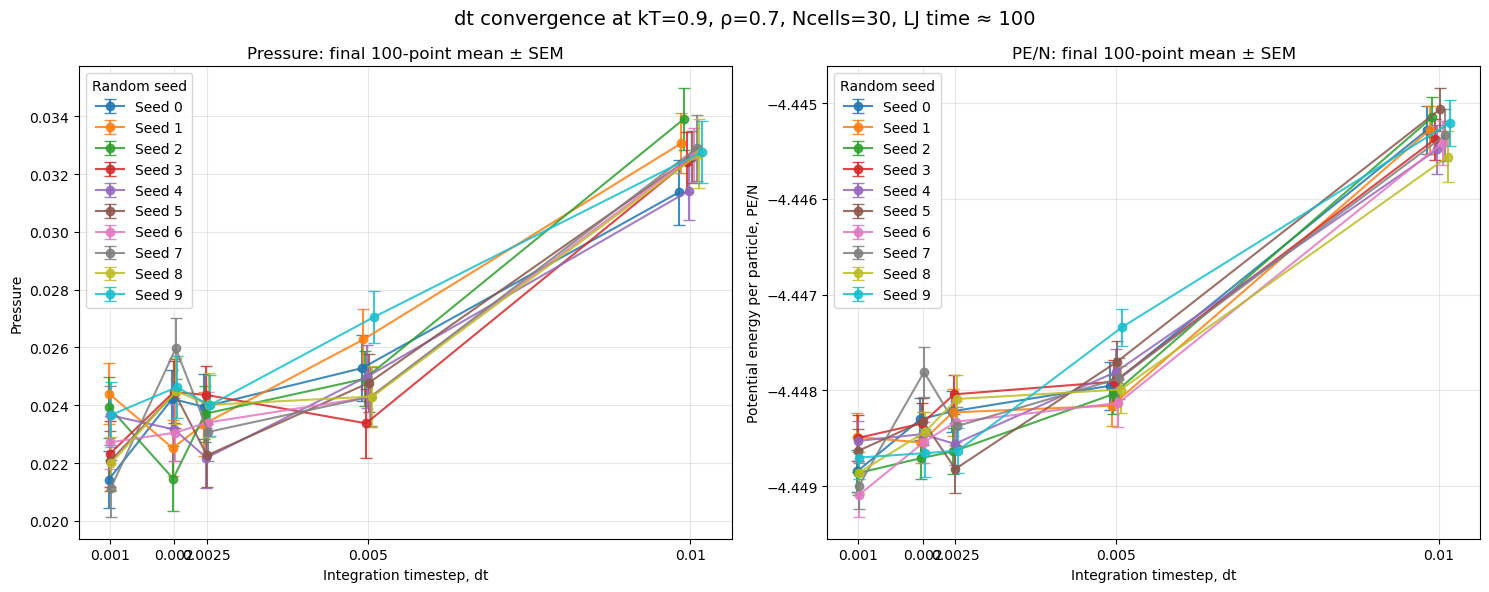

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from md_Helpers import (
    ProjectPaths,
    SQLiteRunDatabase,
    ThermalizationConfig,
    run_thermalization,
)

# ==================================================
# User inputs
# ==================================================

dts = [
    0.001,
    0.002,
    0.0025,
    0.005,
    0.01,
]

# Use one seed or multiple seeds.
seeds = []
for i in range(0,10):
    seeds.append(i)

kT = 0.9
density = 0.7
n_fcc_cells = 30

# Every simulation will evolve for approximately this
# amount of LJ time.
target_lj_time = 100.0

# Each plotted point is the mean of the final 100
# logged samples. Its error bar is the standard error
# of that mean: sample std / sqrt(number of samples).
summary_points = 100

# Generate approximately this many logged points per
# simulation. Keeping this constant makes the final
# 100 samples span approximately the same LJ-time
# interval for every dt.
target_logged_points = 200

# Set True to use a logarithmic dt axis.
use_log_dt_axis = False

# Small visual offset so points from different seeds
# at the same dt do not cover one another.
seed_jitter_fraction = 0.018
#seed_jitter_fraction = 0

# ==================================================
# Setup
# ==================================================

paths = ProjectPaths()
database = SQLiteRunDatabase(paths.database)
database.initialize()

dts = np.asarray(dts, dtype=float)
seeds = [int(seed) for seed in seeds]

if np.any(dts <= 0):
    raise ValueError("Every dt must be positive")

if target_lj_time <= 0:
    raise ValueError("target_lj_time must be positive")

if target_logged_points < summary_points:
    raise ValueError(
        "target_logged_points must be at least summary_points"
    )

results = []

# ==================================================
# Run every dt × seed combination
# ==================================================

for dt in dts:
    # This keeps Nsteps * dt approximately constant.
    nsteps = int(round(target_lj_time / dt))

    if nsteps < target_logged_points:
        raise ValueError(
            f"dt={dt:g} gives only {nsteps:,} steps. "
            f"Increase target_lj_time or reduce "
            f"target_logged_points."
        )

    # Floor division ensures at least approximately
    # target_logged_points evolved log samples.
    log_period = max(
        1,
        nsteps // target_logged_points,
    )

    actual_lj_time = nsteps * dt
    approximate_log_lj_interval = log_period * dt

    for seed in seeds:
        print(
            f"\ndt={dt:g}, seed={seed}, "
            f"Nsteps={nsteps:,}, "
            f"LJ time={actual_lj_time:.6g}, "
            f"log period={log_period:,} steps"
        )

        config = ThermalizationConfig(
            n_fcc_cells=n_fcc_cells,
            target_rho=density,
            nsteps=nsteps,
            kT=kT,
            seed=seed,
            dt=float(dt),
            log_period=log_period,
            summary_num_samples=summary_points,
            pe_drop_n_last=summary_points,
            notes=(
                "dt comparison; "
                f"dt={dt:g}; "
                f"seed={seed}; "
                f"target_lj_time={target_lj_time:g}"
            ),
        )

        run_result = run_thermalization(
            config,
            project_paths=paths,
            database=database,
        )

        run_id = run_result["run_id"]
        status = run_result["status"]

        if status != "Complete":
            raise RuntimeError(
                f"Run {run_id} for dt={dt:g}, seed={seed} "
                f"has Status={status!r}, not 'Complete'."
            )

        summary = database.get_thermalization(run_id)

        if summary is None:
            raise RuntimeError(
                f"Run {run_id} has no Thermalization result row"
            )

        num_samples = int(summary["Summary_Num_Samples"])

        if num_samples != summary_points:
            raise RuntimeError(
                f"Run {run_id} used {num_samples} summary "
                f"samples instead of {summary_points}."
            )

        pressure_std = float(summary["Pressure_Std"])
        pe_per_particle_std = float(
            summary["PE_Per_Particle_Std"]
        )

        # Standard error of each 100-point mean.
        pressure_sem = pressure_std / np.sqrt(num_samples)
        pe_per_particle_sem = (
            pe_per_particle_std / np.sqrt(num_samples)
        )

        results.append(
            {
                "Run_ID": run_id,
                "dt": float(dt),
                "seed": seed,
                "Nsteps": nsteps,
                "actual_lj_time": actual_lj_time,
                "log_period": log_period,
                "log_lj_interval": (
                    approximate_log_lj_interval
                ),
                "summary_samples": num_samples,
                "pressure_mean": float(
                    summary["Pressure_Mean"]
                ),
                "pressure_std": pressure_std,
                "pressure_sem": pressure_sem,
                "pe_per_particle_mean": float(
                    summary["PE_Per_Particle_Mean"]
                ),
                "pe_per_particle_std": pe_per_particle_std,
                "pe_per_particle_sem": pe_per_particle_sem,
                "reused_existing_run": bool(
                    run_result.get("skipped", False)
                ),
            }
        )

# Results table is retained for later analysis.
dt_results = (
    pd.DataFrame(results)
    .sort_values(["seed", "dt"])
    .reset_index(drop=True)
)

display(dt_results)

# Add/update the Master-table note for every dt-test run.
dt_test_note = "These runs are for the dt test."

for run_id in dt_results["Run_ID"].unique():
    database.update_master(
        run_id,
        Notes=dt_test_note,
    )

print(
    f"Updated Notes for "
    f"{dt_results['Run_ID'].nunique()} dt-test runs."
)

# ==================================================
# Plot mean ± standard error for each seed
# ==================================================

fig, (ax_pressure, ax_pe) = plt.subplots(
    1,
    2,
    figsize=(15, 6),
)

colors = plt.cm.tab10(
    np.linspace(0, 1, len(seeds))
)

if len(seeds) == 1:
    jitter_offsets = np.array([0.0])
else:
    jitter_offsets = np.linspace(
        -seed_jitter_fraction,
        seed_jitter_fraction,
        len(seeds),
    )

for color, seed, jitter in zip(
    colors,
    seeds,
    jitter_offsets,
):
    seed_results = (
        dt_results[dt_results["seed"] == seed]
        .sort_values("dt")
    )

    true_dt = seed_results["dt"].to_numpy()

    # Jitter changes only the displayed x-coordinate,
    # not the simulated dt.
    plotted_dt = true_dt * (1.0 + jitter)

    # Pressure: final-100-point mean ± SEM.
    ax_pressure.errorbar(
        plotted_dt,
        seed_results["pressure_mean"],
        yerr=seed_results["pressure_sem"],
        color=color,
        marker="o",
        markersize=6,
        linewidth=1.5,
        capsize=4,
        alpha=0.85,
        label=f"Seed {seed}",
    )

    # PE/N: final-100-point mean ± SEM.
    ax_pe.errorbar(
        plotted_dt,
        seed_results["pe_per_particle_mean"],
        yerr=seed_results["pe_per_particle_sem"],
        color=color,
        marker="o",
        markersize=6,
        linewidth=1.5,
        capsize=4,
        alpha=0.85,
        label=f"Seed {seed}",
    )

# ==================================================
# Formatting
# ==================================================

ax_pressure.set_title(
    f"Pressure: final {summary_points}-point mean ± SEM"
)
ax_pressure.set_xlabel("Integration timestep, dt")
ax_pressure.set_ylabel("Pressure")

ax_pe.set_title(
    f"PE/N: final {summary_points}-point mean ± SEM"
)
ax_pe.set_xlabel("Integration timestep, dt")
ax_pe.set_ylabel("Potential energy per particle, PE/N")

for ax in (ax_pressure, ax_pe):
    if use_log_dt_axis:
        ax.set_xscale("log")

    ax.set_xticks(np.sort(np.unique(dts)))
    ax.set_xticklabels(
        [f"{dt:g}" for dt in np.sort(np.unique(dts))]
    )
    ax.grid(alpha=0.3)
    ax.legend(title="Random seed")

fig.suptitle(
    (
        f"dt convergence at kT={kT:g}, ρ={density:g}, "
        f"Ncells={n_fcc_cells}, "
        f"LJ time ≈ {target_lj_time:g}"
    ),
    fontsize=14,
)

plt.tight_layout()
plt.show()


dt=0.0001, seed=0, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=1, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=2, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=3, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=4, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=5, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=6, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=7, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=8, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=9, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=10, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=11, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=12, Nsteps=1,000,000, LJ time=100, log period=5,000 steps

dt=0.0001, seed=13, Nsteps=1,000,0

,Run_ID,dt,seed,Nsteps,actual_lj_time,log_period,log_lj_interval,summary_samples,pressure_mean,pressure_std,pressure_sem,pe_per_particle_mean,pe_per_particle_std,pe_per_particle_sem,reused_existing_run
0,20260915151026,0.0001,0,1000000,100.0,5000,0.5,100,0.358033,0.010053,0.001005,-4.378712,0.002304,0.000230,True
1,20260914170629,0.0005,0,200000,100.0,1000,0.5,100,0.360200,0.011508,0.001151,-4.378385,0.002442,0.000244,True
2,20260914172127,0.0010,0,100000,100.0,500,0.5,100,0.358796,0.009013,0.000901,-4.378686,0.002136,0.000214,True
3,20260914172929,0.0020,0,50000,100.0,250,0.5,100,0.358887,0.011537,0.001154,-4.378678,0.002388,0.000239,True
4,20260914173406,0.0025,0,40000,100.0,200,0.5,100,0.360069,0.010651,0.001065,-4.378257,0.002326,0.000233,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,20260915215600,0.0005,14,200000,100.0,1000,0.5,100,0.358520,0.011543,0.001154,-4.378718,0.002407,0.000241,True
86,20260915220528,0.0010,14,100000,100.0,500,0.5,100,0.359536,0.011417,0.001142,-4.378125,0.002448,0.000245,True
87,20260915221044,0.0020,14,50000,100.0,250,0.5,100,0.360791,0.010182,0.001018,-4.377658,0.002462,0.000246,True
88,20260915221453,0.0025,14,40000,100.0,200,0.5,100,0.359057,0.010859,0.001086,-4.378488,0.002365,0.000236,True



Mean across seeds at each dt:


,dt,pressure_mean,pressure_seed_std,pe_per_particle_mean,pe_per_particle_seed_std,num_seeds,pressure_seed_sem,pe_per_particle_seed_sem
0,0.0001,0.358263,0.001500,-4.378616,0.000306,15,0.000387,0.000079
1,0.0005,0.358174,0.001389,-4.378558,0.000323,15,0.000359,0.000084
2,0.0010,0.358621,0.001185,-4.378512,0.000298,15,0.000306,0.000077
3,0.0020,0.358727,0.001045,-4.378471,0.000305,15,0.000270,0.000079
4,0.0025,0.358551,0.001027,-4.378453,0.000230,15,0.000265,0.000059
5,0.0050,0.360492,0.001272,-4.377729,0.000217,15,0.000328,0.000056


Updated Notes for 90 dt-test runs.


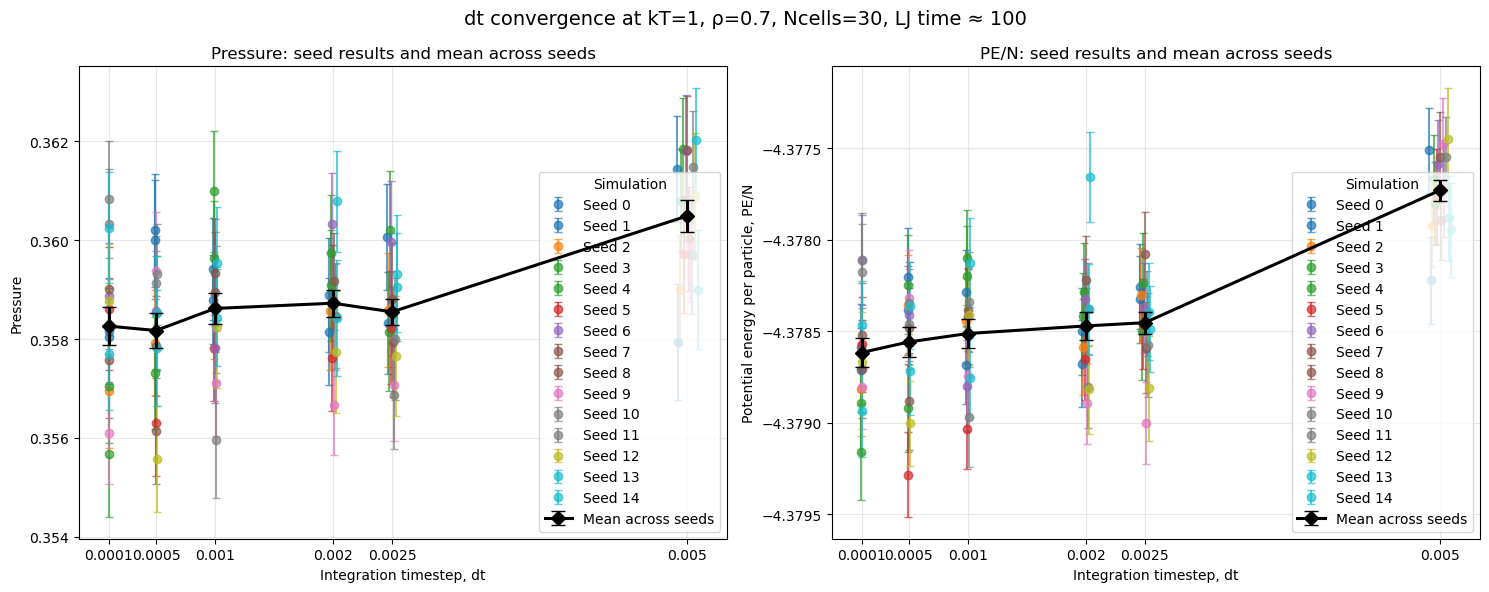

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from md_Helpers import (
    ProjectPaths,
    SQLiteRunDatabase,
    ThermalizationConfig,
    run_thermalization,
)

# ==================================================
# User inputs
# ==================================================

dts = [
    0.0001,
    0.0005,    
    0.001,
    0.002,
    0.0025,
    0.005,
    #0.01,
]

# Use one seed or multiple seeds.
seeds = []
for i in range(0,15):
    seeds.append(i)


#kT=.9
kT = 1.0

density = 0.7
n_fcc_cells = 30

target_lj_time = 100.0

# Each seed-level point is calculated from the final
# 100 logged samples.
summary_points = 100

target_logged_points = 200

use_log_dt_axis = False

# Small visual offset so seed points at the same dt
# do not cover one another.
seed_jitter_fraction = 0.018

# ==================================================
# Setup
# ==================================================

paths = ProjectPaths()
database = SQLiteRunDatabase(paths.database)
database.initialize()

dts = np.asarray(dts, dtype=float)
seeds = [int(seed) for seed in seeds]

if np.any(dts <= 0):
    raise ValueError("Every dt must be positive")

if target_lj_time <= 0:
    raise ValueError("target_lj_time must be positive")

if target_logged_points < summary_points:
    raise ValueError(
        "target_logged_points must be at least summary_points"
    )

results = []

# ==================================================
# Run every dt × seed combination
# ==================================================

for dt in dts:
    # Keep Nsteps × dt approximately constant.
    nsteps = int(round(target_lj_time / dt))

    if nsteps < target_logged_points:
        raise ValueError(
            f"dt={dt:g} gives only {nsteps:,} steps. "
            f"Increase target_lj_time or reduce "
            f"target_logged_points."
        )

    log_period = max(
        1,
        nsteps // target_logged_points,
    )

    actual_lj_time = nsteps * dt
    approximate_log_lj_interval = log_period * dt

    for seed in seeds:
        print(
            f"\ndt={dt:g}, seed={seed}, "
            f"Nsteps={nsteps:,}, "
            f"LJ time={actual_lj_time:.6g}, "
            f"log period={log_period:,} steps"
        )

        config = ThermalizationConfig(
            n_fcc_cells=n_fcc_cells,
            target_rho=density,
            nsteps=nsteps,
            kT=kT,
            seed=seed,
            dt=float(dt),
            log_period=log_period,
            summary_num_samples=summary_points,
            pe_drop_n_last=summary_points,
            notes=(
                "dt comparison; "
                f"dt={dt:g}; "
                f"seed={seed}; "
                f"target_lj_time={target_lj_time:g}"
            ),
        )

        run_result = run_thermalization(
            config,
            project_paths=paths,
            database=database,
        )

        run_id = run_result["run_id"]
        status = run_result["status"]

        if status != "Complete":
            raise RuntimeError(
                f"Run {run_id} for dt={dt:g}, seed={seed} "
                f"has Status={status!r}, not 'Complete'."
            )

        summary = database.get_thermalization(run_id)

        if summary is None:
            raise RuntimeError(
                f"Run {run_id} has no Thermalization result row"
            )

        num_samples = int(summary["Summary_Num_Samples"])

        if num_samples != summary_points:
            raise RuntimeError(
                f"Run {run_id} used {num_samples} summary "
                f"samples instead of {summary_points}."
            )

        pressure_std = float(summary["Pressure_Std"])
        pe_per_particle_std = float(
            summary["PE_Per_Particle_Std"]
        )

        # Within-run SEM of the final 100 logged samples.
        pressure_sem = (
            pressure_std / np.sqrt(num_samples)
        )
        pe_per_particle_sem = (
            pe_per_particle_std / np.sqrt(num_samples)
        )

        results.append(
            {
                "Run_ID": run_id,
                "dt": float(dt),
                "seed": seed,
                "Nsteps": nsteps,
                "actual_lj_time": actual_lj_time,
                "log_period": log_period,
                "log_lj_interval": (
                    approximate_log_lj_interval
                ),
                "summary_samples": num_samples,
                "pressure_mean": float(
                    summary["Pressure_Mean"]
                ),
                "pressure_std": pressure_std,
                "pressure_sem": pressure_sem,
                "pe_per_particle_mean": float(
                    summary["PE_Per_Particle_Mean"]
                ),
                "pe_per_particle_std": pe_per_particle_std,
                "pe_per_particle_sem": pe_per_particle_sem,
                "reused_existing_run": bool(
                    run_result.get("skipped", False)
                ),
            }
        )

# ==================================================
# Results tables
# ==================================================

dt_results = (
    pd.DataFrame(results)
    .sort_values(["seed", "dt"])
    .reset_index(drop=True)
)

display(dt_results)

# Mean across independent seeds at each dt.
#
# The seed-level SEM is:
#     standard deviation across seed means / sqrt(number of seeds)
seed_means = (
    dt_results
    .groupby("dt", as_index=False)
    .agg(
        pressure_mean=("pressure_mean", "mean"),
        pressure_seed_std=("pressure_mean", "std"),
        pe_per_particle_mean=(
            "pe_per_particle_mean",
            "mean",
        ),
        pe_per_particle_seed_std=(
            "pe_per_particle_mean",
            "std",
        ),
        num_seeds=("seed", "nunique"),
    )
    .sort_values("dt")
)

seed_means["pressure_seed_sem"] = (
    seed_means["pressure_seed_std"]
    / np.sqrt(seed_means["num_seeds"])
)

seed_means["pe_per_particle_seed_sem"] = (
    seed_means["pe_per_particle_seed_std"]
    / np.sqrt(seed_means["num_seeds"])
)

print("\nMean across seeds at each dt:")
display(seed_means)

# Add/update the Master-table note.
dt_test_note = "These runs are for the dt test."

for run_id in dt_results["Run_ID"].unique():
    database.update_master(
        run_id,
        Notes=dt_test_note,
    )

print(
    f"Updated Notes for "
    f"{dt_results['Run_ID'].nunique()} dt-test runs."
)

# ==================================================
# Plot
# ==================================================

fig, (ax_pressure, ax_pe) = plt.subplots(
    1,
    2,
    figsize=(15, 6),
)

colors = plt.cm.tab10(
    np.linspace(0, 1, len(seeds))
)

if len(seeds) == 1:
    jitter_offsets = np.array([0.0])
else:
    jitter_offsets = np.linspace(
        -seed_jitter_fraction,
        seed_jitter_fraction,
        len(seeds),
    )

# --------------------------------------------------
# Individual seed points: no connecting lines
# --------------------------------------------------

for color, seed, jitter in zip(
    colors,
    seeds,
    jitter_offsets,
):
    seed_results = (
        dt_results[dt_results["seed"] == seed]
        .sort_values("dt")
    )

    true_dt = seed_results["dt"].to_numpy()

    # Jitter changes only the displayed x-coordinate.
    plotted_dt = true_dt * (1.0 + jitter)

    ax_pressure.errorbar(
        plotted_dt,
        seed_results["pressure_mean"],
        yerr=seed_results["pressure_sem"],
        color=color,
        marker="o",
        linestyle="none",
        markersize=6,
        capsize=3,
        alpha=0.7,
        label=f"Seed {seed}",
    )

    ax_pe.errorbar(
        plotted_dt,
        seed_results["pe_per_particle_mean"],
        yerr=seed_results["pe_per_particle_sem"],
        color=color,
        marker="o",
        linestyle="none",
        markersize=6,
        capsize=3,
        alpha=0.7,
        label=f"Seed {seed}",
    )

# --------------------------------------------------
# Mean across seeds: connected line
# --------------------------------------------------

ax_pressure.errorbar(
    seed_means["dt"],
    seed_means["pressure_mean"],
    yerr=seed_means["pressure_seed_sem"],
    color="black",
    marker="D",
    linestyle="-",
    linewidth=2.2,
    markersize=7,
    capsize=5,
    zorder=10,
    label="Mean across seeds",
)

ax_pe.errorbar(
    seed_means["dt"],
    seed_means["pe_per_particle_mean"],
    yerr=seed_means["pe_per_particle_seed_sem"],
    color="black",
    marker="D",
    linestyle="-",
    linewidth=2.2,
    markersize=7,
    capsize=5,
    zorder=10,
    label="Mean across seeds",
)

# ==================================================
# Formatting
# ==================================================

ax_pressure.set_title(
    "Pressure: seed results and mean across seeds"
)
ax_pressure.set_xlabel("Integration timestep, dt")
ax_pressure.set_ylabel("Pressure")

ax_pe.set_title(
    "PE/N: seed results and mean across seeds"
)
ax_pe.set_xlabel("Integration timestep, dt")
ax_pe.set_ylabel(
    "Potential energy per particle, PE/N"
)

for ax in (ax_pressure, ax_pe):
    if use_log_dt_axis:
        ax.set_xscale("log")

    ax.set_xticks(np.sort(np.unique(dts)))
    ax.set_xticklabels(
        [f"{dt:g}" for dt in np.sort(np.unique(dts))]
    )

    ax.grid(alpha=0.3)
    ax.legend(title="Simulation")

fig.suptitle(
    (
        f"dt convergence at kT={kT:g}, "
        f"ρ={density:g}, "
        f"Ncells={n_fcc_cells}, "
        f"LJ time ≈ {target_lj_time:g}"
    ),
    fontsize=14,
)

plt.tight_layout()
plt.show()

Percent differences relative to dt=0.0001:


,dt,pressure_percent_mean,pressure_percent_std,pe_percent_mean,pe_percent_std,num_seeds,pressure_percent_sem,pe_percent_sem
0,0.0001,0.000000,0.000000,0.000000,0.000000,15,0.000000,0.000000
1,0.0005,-0.023269,0.548999,0.001323,0.010189,15,0.141751,0.002631
2,0.0010,0.101927,0.598767,0.002376,0.011192,15,0.154601,0.002890
3,0.0020,0.130844,0.440906,0.003323,0.009630,15,0.113841,0.002486
4,0.0025,0.082605,0.571391,0.003729,0.009106,15,0.147532,0.002351
5,0.0050,0.624287,0.598664,0.020258,0.008137,15,0.154574,0.002101


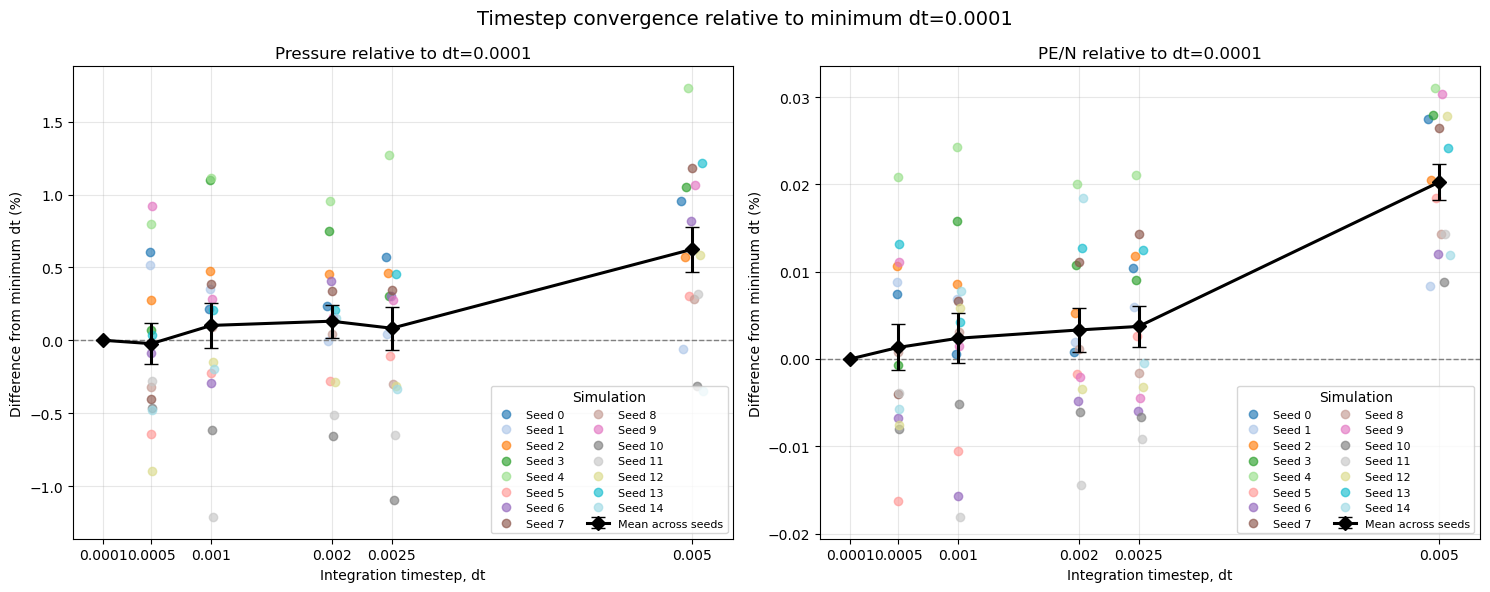

In [17]:
# ==================================================
# Percent difference relative to the minimum dt
# ==================================================

reference_dt = dt_results["dt"].min()

# Reference values for each seed at the smallest dt.
reference_values = (
    dt_results.loc[
        dt_results["dt"] == reference_dt,
        [
            "seed",
            "pressure_mean",
            "pe_per_particle_mean",
        ],
    ]
    .rename(
        columns={
            "pressure_mean": "pressure_reference",
            "pe_per_particle_mean": "pe_reference",
        }
    )
)

# Match every result to the minimum-dt result from
# the same seed.
percent_results = dt_results.merge(
    reference_values,
    on="seed",
    how="left",
    validate="many_to_one",
)

# Signed percent difference:
#
# 100 * (value - reference) / abs(reference)
#
# Using abs(reference) in the denominator gives a
# sensible sign for the negative PE/N values.
percent_results["pressure_percent_difference"] = (
    100.0
    * (
        percent_results["pressure_mean"]
        - percent_results["pressure_reference"]
    )
    / np.abs(percent_results["pressure_reference"])
)

percent_results["pe_percent_difference"] = (
    100.0
    * (
        percent_results["pe_per_particle_mean"]
        - percent_results["pe_reference"]
    )
    / np.abs(percent_results["pe_reference"])
)

# Mean and SEM of the paired percent differences
# across independent seeds.
percent_summary = (
    percent_results
    .groupby("dt", as_index=False)
    .agg(
        pressure_percent_mean=(
            "pressure_percent_difference",
            "mean",
        ),
        pressure_percent_std=(
            "pressure_percent_difference",
            "std",
        ),
        pe_percent_mean=(
            "pe_percent_difference",
            "mean",
        ),
        pe_percent_std=(
            "pe_percent_difference",
            "std",
        ),
        num_seeds=("seed", "nunique"),
    )
    .sort_values("dt")
)

percent_summary["pressure_percent_sem"] = (
    percent_summary["pressure_percent_std"]
    / np.sqrt(percent_summary["num_seeds"])
)

percent_summary["pe_percent_sem"] = (
    percent_summary["pe_percent_std"]
    / np.sqrt(percent_summary["num_seeds"])
)

print(
    f"Percent differences relative to dt={reference_dt:g}:"
)
display(percent_summary)

# ==================================================
# Plot
# ==================================================

fig, (ax_pressure_pct, ax_pe_pct) = plt.subplots(
    1,
    2,
    figsize=(15, 6),
)

colors = plt.cm.tab20(
    np.linspace(0, 1, len(seeds))
)

if len(seeds) == 1:
    jitter_offsets = np.array([0.0])
else:
    jitter_offsets = np.linspace(
        -seed_jitter_fraction,
        seed_jitter_fraction,
        len(seeds),
    )

# Individual paired seed results with no connecting lines.
for color, seed, jitter in zip(
    colors,
    seeds,
    jitter_offsets,
):
    seed_percent = (
        percent_results[
            percent_results["seed"] == seed
        ]
        .sort_values("dt")
    )

    plotted_dt = (
        seed_percent["dt"].to_numpy()
        * (1.0 + jitter)
    )

    ax_pressure_pct.plot(
        plotted_dt,
        seed_percent["pressure_percent_difference"],
        color=color,
        marker="o",
        linestyle="none",
        markersize=6,
        alpha=0.65,
        label=f"Seed {seed}",
    )

    ax_pe_pct.plot(
        plotted_dt,
        seed_percent["pe_percent_difference"],
        color=color,
        marker="o",
        linestyle="none",
        markersize=6,
        alpha=0.65,
        label=f"Seed {seed}",
    )

# Mean across seeds, connected by a black line.
ax_pressure_pct.errorbar(
    percent_summary["dt"],
    percent_summary["pressure_percent_mean"],
    yerr=percent_summary["pressure_percent_sem"],
    color="black",
    marker="D",
    linestyle="-",
    linewidth=2.2,
    markersize=7,
    capsize=5,
    zorder=10,
    label="Mean across seeds",
)

ax_pe_pct.errorbar(
    percent_summary["dt"],
    percent_summary["pe_percent_mean"],
    yerr=percent_summary["pe_percent_sem"],
    color="black",
    marker="D",
    linestyle="-",
    linewidth=2.2,
    markersize=7,
    capsize=5,
    zorder=10,
    label="Mean across seeds",
)

# Zero means exact agreement with the minimum dt.
ax_pressure_pct.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1,
)

ax_pe_pct.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1,
)

ax_pressure_pct.set_title(
    f"Pressure relative to dt={reference_dt:g}"
)
ax_pressure_pct.set_xlabel("Integration timestep, dt")
ax_pressure_pct.set_ylabel(
    "Difference from minimum dt (%)"
)

ax_pe_pct.set_title(
    f"PE/N relative to dt={reference_dt:g}"
)
ax_pe_pct.set_xlabel("Integration timestep, dt")
ax_pe_pct.set_ylabel(
    "Difference from minimum dt (%)"
)

for ax in (ax_pressure_pct, ax_pe_pct):
    if use_log_dt_axis:
        ax.set_xscale("log")

    ax.set_xticks(np.sort(dt_results["dt"].unique()))
    ax.set_xticklabels(
        [
            f"{dt:g}"
            for dt in np.sort(
                dt_results["dt"].unique()
            )
        ]
    )

    ax.grid(alpha=0.3)
    ax.legend(
        title="Simulation",
        fontsize=8,
        ncol=2,
    )

fig.suptitle(
    (
        "Timestep convergence relative to "
        f"minimum dt={reference_dt:g}"
    ),
    fontsize=14,
)

plt.tight_layout()
plt.show()